## Spot filtrr

The code in this notebook takes the raw spot counts and metrics generated by spot-findr.ipynb and the cell metrics generated by img-explorer.ipynb and aims to filter true spots for each true cell

In [1]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9 
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# Define the repo directory where the data are located
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory

# List the experiments to read data for
experiment_list = ["10092025_pb-mSG_Cen-ZF_batch1", "10102025_pb-mSG_Cen-ZF_batch2"]
#experiment_list = ["02112025_Cen-ZF_select_HCT116_session1", "02132025_Cen-ZF_select_HCT116_session2"]

We have cells with a given number of spots. Let's first see what's the distribution of spots for each experimental group

In [3]:
# Read in raw data generated by spot-findr.ipynb

# Initialize lists to hold the spot counts and spot metrics data
spot_counts_list = []
spot_metrics_list = []

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Build the path to the experimental-groups.csv file
    counts_path = os.path.join(repo_directory, "results", experiment, "spot_counts-raw.csv")
    metrics_path = os.path.join(repo_directory, "results", experiment, "spot_metrics-raw.csv")
    
    try:
        # Read the CSV files
        counts_df = pd.read_csv(counts_path)
        metrics_df = pd.read_csv(metrics_path)
        
        # Append the DataFrame to the list
        spot_counts_list.append(counts_df)
        spot_metrics_list.append(metrics_df)
        
    except Exception as e:
        logging.error(f"Error reading {counts_path} for experiment {experiment}: {str(e)}")
        logging.error(f"Error reading {metrics_path} for experiment {experiment}: {str(e)}")

# Combine all experimental groups into a single DataFrame
raw_spot_counts = pd.concat(spot_counts_list, ignore_index=True)
raw_spot_metrics = pd.concat(spot_metrics_list, ignore_index=True)

In [4]:
# Similarly, read in the cell_metrics data frame 
# and extract the ROIs in each image that are true cells (not removed in outlie removal)

# Initialize a list to hold the cell_metrics data
cell_metrics_list = []

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Build the path to the experimental-groups.csv file
    metrics_path = os.path.join(repo_directory, "results", experiment, "cell_metrics_postBS.csv")
    
    try:
        # Read the CSV files
        metrics_df = pd.read_csv(metrics_path)
        
        # Append the DataFrame to the list
        cell_metrics_list.append(metrics_df)
        
    except Exception as e:
        logging.error(f"Error reading {metrics_path} for experiment {experiment}: {str(e)}")

# Combine all experimental groups into a single DataFrame
cell_metrics = pd.concat(cell_metrics_list, ignore_index=True)

# Rename ROI_index to ROI
cell_metrics.rename(columns = {"ROI_index": "ROI"}, inplace = True)

# Turn channel from 0-indexed to 1-indexed
cell_metrics['channel'] = cell_metrics['channel'] + 1

# Print the top of the data frame for inspection
#print(cell_metrics.head())

In [5]:
# Filter spot_counts and spot_metrics so that they keep only the ROIs in cell_metrics
# since the entries in cell_metrics have undergone outlier removal

# Define the common keys to merge by:
common_keys = ['experiment', 'base_name', 'ROI', 'channel']

# Select true cells in spot_counts: keep only rows present in cell_metrics
raw_spot_counts = raw_spot_counts.merge(cell_metrics[common_keys], on = common_keys, how = 'inner')

# Select true cells in spot_metrics similarly
raw_spot_metrics = raw_spot_metrics.merge(cell_metrics[common_keys], on = common_keys, how = 'inner')

In [6]:
print(raw_spot_counts.head())
print(raw_spot_metrics.head())

                      experiment  \
0  10092025_pb-mSG_Cen-ZF_batch1   
1  10092025_pb-mSG_Cen-ZF_batch1   
2  10092025_pb-mSG_Cen-ZF_batch1   
3  10092025_pb-mSG_Cen-ZF_batch1   
4  10092025_pb-mSG_Cen-ZF_batch1   

                                      base_name  ROI  channel  spot_count  \
0  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    2        2           0   
1  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    3        2           0   
2  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    5        2           1   
3  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    6        2           0   
4  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    7        2           0   

                      plasmid  
0  pb_mSG_Cen8-ZF3a_v2_SV40pA  
1  pb_mSG_Cen8-ZF3a_v2_SV40pA  
2  pb_mSG_Cen8-ZF3a_v2_SV40pA  
3  pb_mSG_Cen8-ZF3a_v2_SV40pA  
4  pb_mSG_Cen8-ZF3a_v2_SV40pA  
                      experiment  \
0  10092025_pb-mSG_Cen-ZF_batch1   
1  10092025_pb-mSG_Cen-ZF_batch1   
2  10092025_pb-mSG_C

/Users/nestor/anaconda3/envs/pyimage-env/lib/python3.12/site-packages/plotnine/themes/themeable.py:2438: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


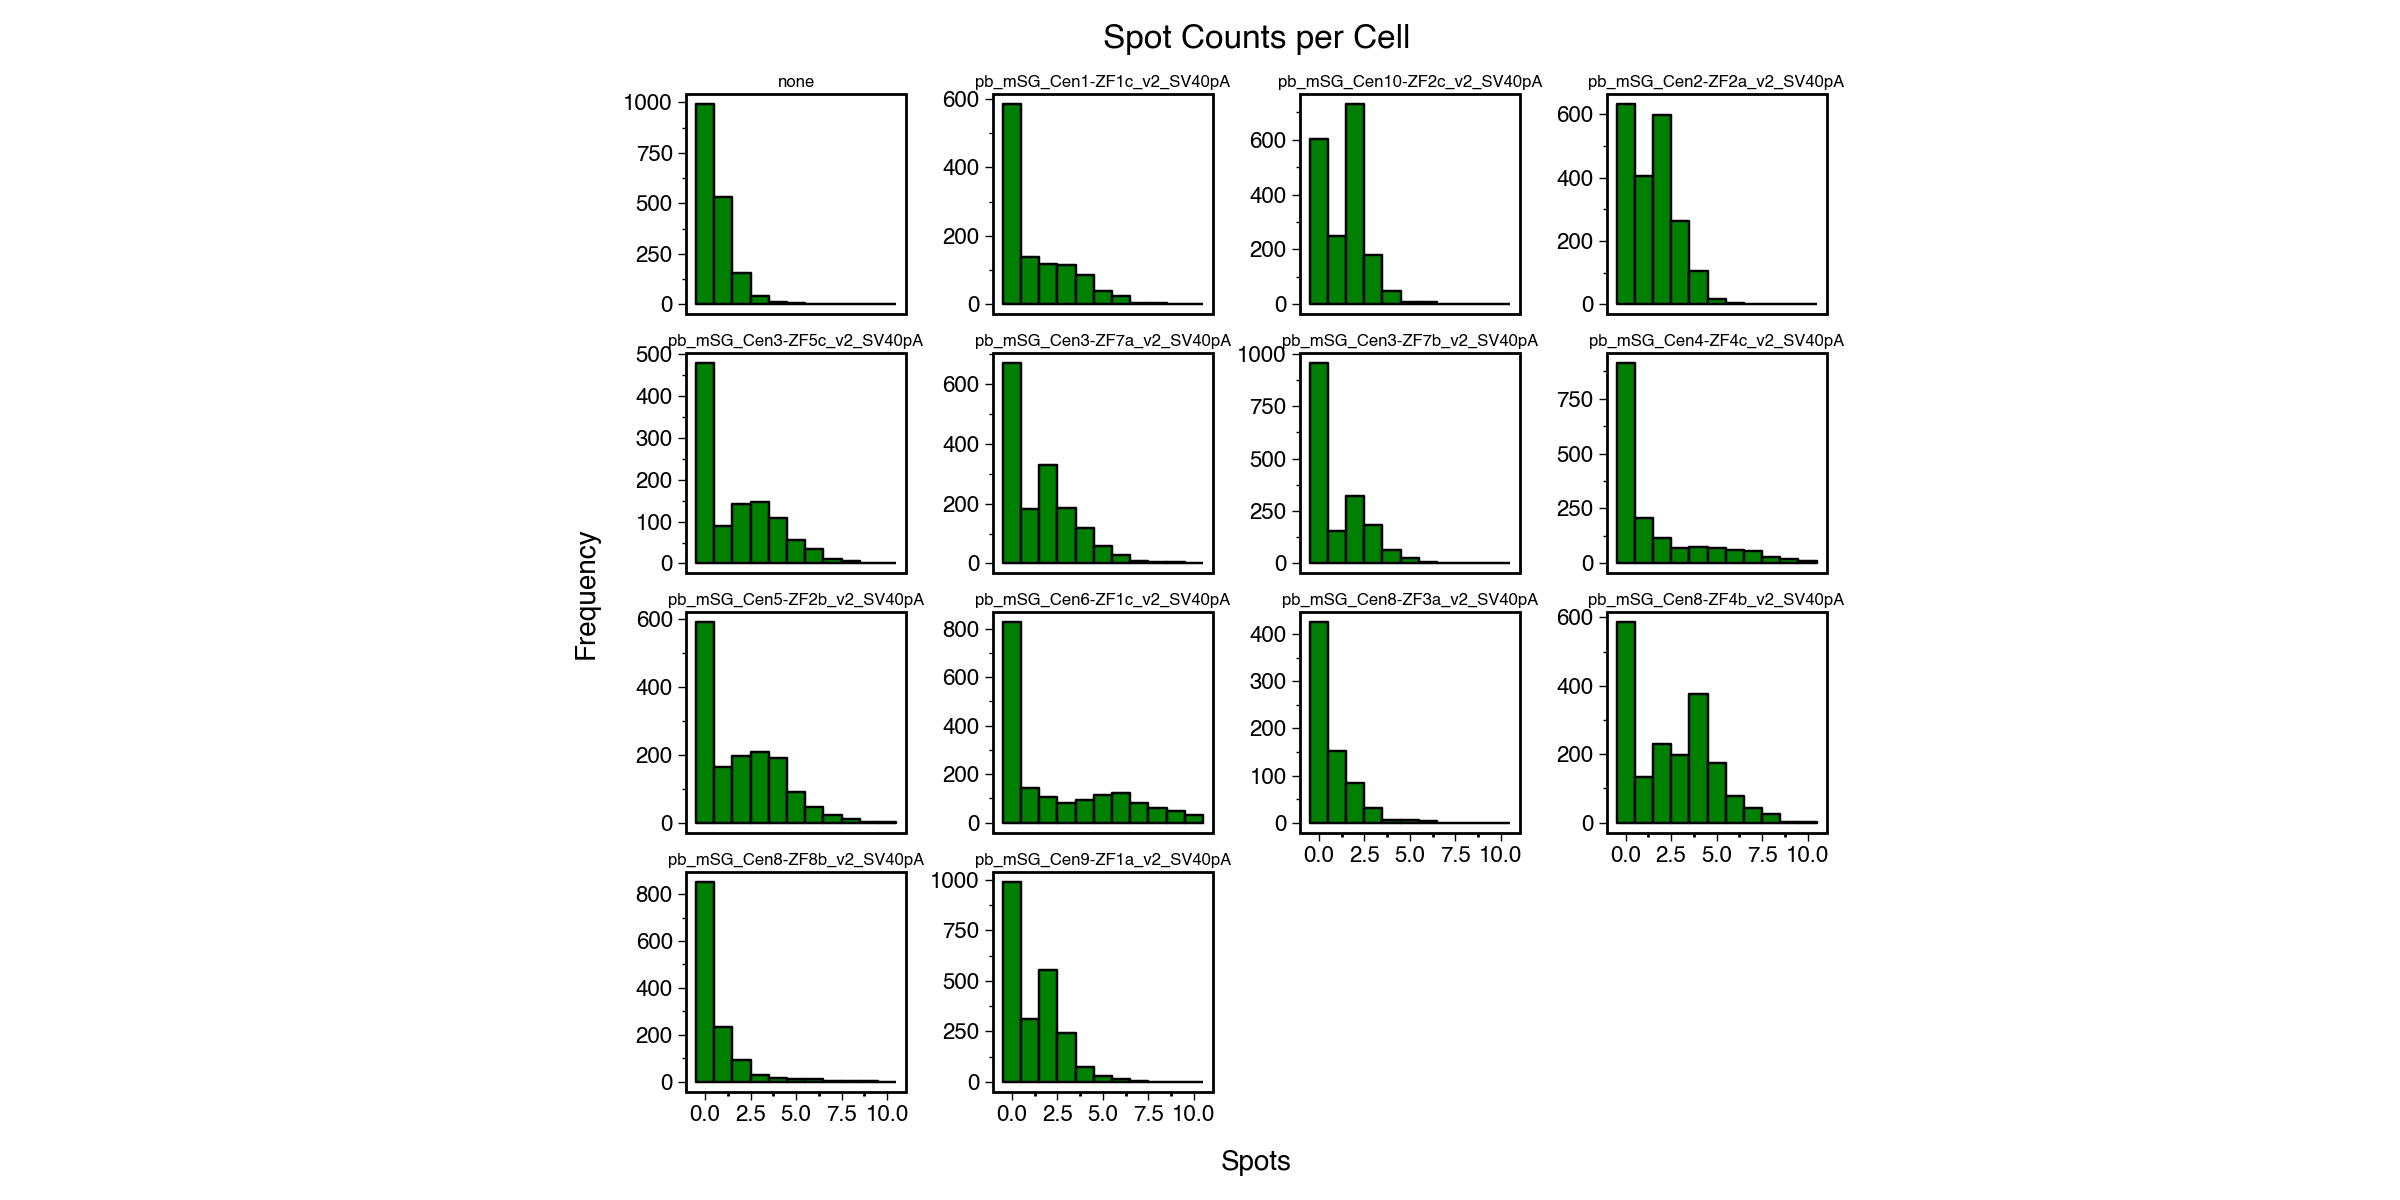

In [7]:
# Plot the number of spots found for all ROIs in all images, 
# separated by experimental group and channel
# This is the raw number of spots found by spot-findr, but this plotting code omits cells with 0 spots, for some reason

# Define a dictionary of channel colors
channel_colors = {1: 'blue', 2: 'green', 3: 'magenta', 4: 'cyan'}

# Define some list of values to filter by

# Reorder channels so that Channel 2 (GFP) is plotted over Channel 3 (FISH)
#spot_filter_counts['channel'] = pd.Categorical(spot_filter_counts['channel'], categories=[3, 2], ordered=True)

# Determine the largest number of spots to set the X axis of the plot
#max_spot_count = spot_df['spot_count'].max()
max_spot_count = 10

#my_spots = spot_counts[spot_counts['channel'].isin([2,3])]
my_spots = raw_spot_counts[(raw_spot_counts['experiment'] == experiment_list[0]) & 
                            (raw_spot_counts['spot_count'] <= max_spot_count)]

# Define the plot with overlaid histograms for each channel
spot_histogram_raw = (
    p9.ggplot(my_spots, 
              p9.aes(x = 'spot_count', 
                     fill = 'factor(channel)')) +  # Set the data and x-axis aesthetic
    p9.geom_histogram(binwidth = 1, color = 'black') +  # Overlaid histograms
    p9.labs(title = 'Spot Counts per Cell', 
            x = 'Spots', y = 'Frequency', fill = 'Channel') +  # Add labels
    #p9.facet_wrap(' ~ channel + group', scales = "free_y", nrow = 2) +
    p9.facet_wrap(' ~ plasmid', scales = 'free_y') +
    p9.scale_fill_manual(values = channel_colors) +  # Apply the custom channel colors
    #p9.scale_x_discrete(limits = [0, max_spot_count], breaks = [0, 8, by = 2]) + 
    p9.theme_bw() +  # Apply theme
    p9.theme(figure_size = (12, 6),
             subplots_adjust = {'wspace': 0.2},  # Adjust space between plots
             aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color='black', linewidth=1), 
             axis_ticks = p9.element_line(color='black', linewidth=0.5), 
             plot_title = p9.element_text(size=12, color='black', face='bold'),
             axis_text = p9.element_text(size=8, color='black'), 
             axis_title = p9.element_text(size=10, color='black', face='bold'), 
             legend_text = p9.element_text(size=8, color='black'), 
             legend_title = p9.element_text(size=10, color='black', face='bold'),
             legend_position = 'none',
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size=6, color='black'))
)

# Display the plot
spot_histogram_raw

Before looking at spot intensities, let's do two operations:
1. Perform background subtraction for the spot intensity, as it was done for the nuclear intensity in img-explorer.ipynb
2. Calculate the signal to background (SBR) for each spot

In [8]:
# 1. Spot intensity background subtraction:

# Read in background_metrics data frames
# determine below the background intensity  metric to keep (avg_intensity, median_intensity or min_intensity)

bk_value = "min_intensity"

# Initialize a list to hold the cell_metrics data
bk_metrics_list = []

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Build the path to the experimental-groups.csv file
    bk_path = os.path.join(repo_directory, "results", experiment, "background_metrics.csv")
    
    try:
        # Read the CSV files
        bk_df = pd.read_csv(bk_path)
        
        # Append the DataFrame to the list
        bk_metrics_list.append(bk_df)
        
    except Exception as e:
        logging.error(f"Error reading {bk_path} for experiment {experiment}: {str(e)}")

# Combine all experimental groups into a single DataFrame
bk_metrics = pd.concat(bk_metrics_list, ignore_index=True)

# Turn channel from 0-indexed to 1-indexed
bk_metrics['channel'] = bk_metrics['channel'] + 1

# Select only essential columns
bk_metrics = bk_metrics[['experiment', 'base_name', 'channel', bk_value]]

In [9]:
# Incorporate background metric into spot_metrics data frame by merging them
spot_metricsBS = pd.merge(raw_spot_metrics, 
                        bk_metrics, 
                        on = ['experiment', 'base_name', 'channel'], 
                        how = "left")

# and subtract the selected bk_value from the spot intensity value
spot_metricsBS['intensity'] = spot_metricsBS['intensity'] - spot_metricsBS[bk_value]

# remove background intensity values, to avoid confusion later
del spot_metricsBS['min_intensity']

In [10]:
# 2. SBR calculation:

# Define the variables to merge by from the cell_metrics data frame, as done earlier
# these will be used to select and merge with spot_metricsBS
common_keys = ['experiment', 'base_name', 'ROI', 'channel']
metrics_to_add = ['median', 'maxima']

# Incorporate cell metrics into spot_metricsBS data frame
spot_metricsBS = pd.merge(spot_metricsBS, 
                          cell_metrics[common_keys + metrics_to_add], 
                          on = common_keys, 
                          how = 'left')

# Calculate a new variable, SBR, that's the intensity of the spot divided by the nucleus median
spot_metricsBS['sbr'] = spot_metricsBS['intensity'] / spot_metricsBS['median']

10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP (Channel 2): 85 spots
10092025_pbCen-ZF_pNS0560_1_MMStack_Pos13_MIP (Channel 2): 317 spots
10092025_pbCen-ZF_pNS0565_1_MMStack_Pos4_MIP (Channel 2): 47 spots
10092025_pbCen-ZF_pNS0557_1_MMStack_Pos13_MIP (Channel 2): 125 spots


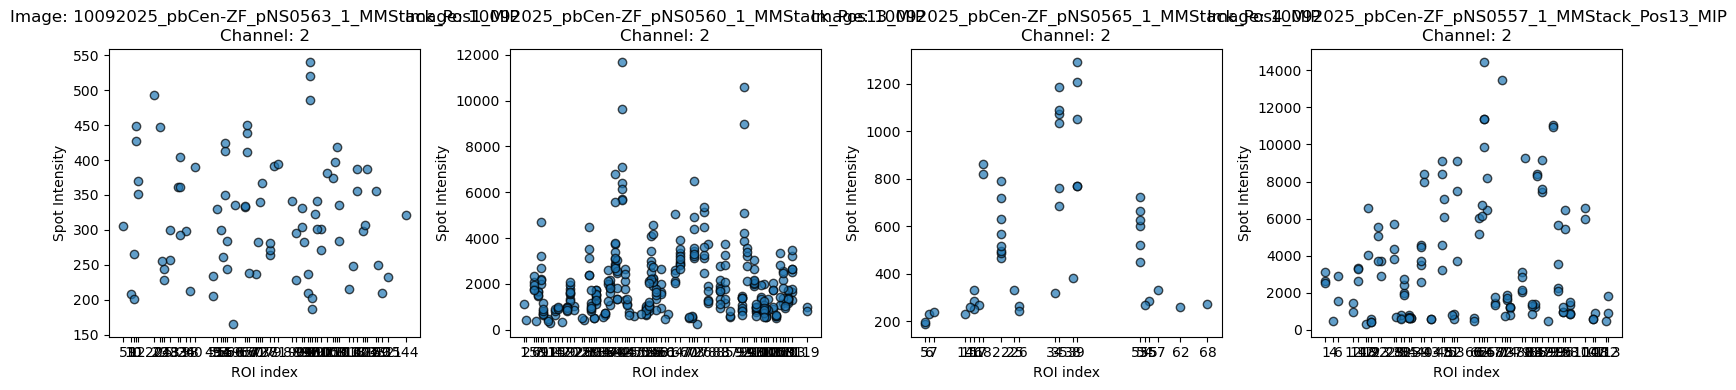

In [11]:
# Assess spot intensity distribution

# Pick images to plot, by index
selected_indices = list(range(4))

# Pick the channel to plot
c = 2

# or by name
# base_name_to_plot = "example_name"

# 1. Filter spot_metricsBS such that it includes images only with spots for channel c.

# Filter spot_counts to only include rows for channel c and a positive spot count.
images_with_spots = raw_spot_counts[(raw_spot_counts['spot_count'] > 0) & 
                                    (raw_spot_counts['channel'] == c)]['base_name'].unique()
# Filter spot_metrics to include only these images.
spot_metrics_yespots = spot_metricsBS[spot_metricsBS['base_name'].isin(images_with_spots)]

# 2. Select images to plot from the filtered data.

# Here, we'll use a selection of indices from the unique base_names in spot_metrics_yespots.
unique_base_names = spot_metrics_yespots['base_name'].unique()
images_to_plot = [unique_base_names[i] for i in selected_indices if i < len(unique_base_names)]

# Define the grid dimensions.
n_images = len(images_to_plot)
ncols = 4
nrows = int(np.ceil(n_images / ncols))

# Create subplots grid.
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), squeeze=False)

# Loop over each selected image and plot it.
for idx, base_name in enumerate(images_to_plot):
    ax = axes[idx // ncols, idx % ncols]
    
    # Filter the DataFrame for the current image.
    subset = spot_metrics_yespots[(spot_metrics_yespots['base_name'] == base_name) &
                                  (spot_metrics_yespots['channel'] == c)]
    
    print(f"{base_name} (Channel {c}): {len(subset)} spots")
    
    # Create a scatter plot: ROI index on x-axis, spot intensity on y-axis.
    ax.scatter(subset['ROI'], subset['intensity'], alpha=0.7, edgecolor='black')
    ax.set_title(f"Image: {base_name}\nChannel: {c}")
    ax.set_xlabel("ROI index")
    ax.set_ylabel("Spot Intensity")
    
    # Set x-axis ticks to show unique integer ROI values.
    unique_rois = np.sort(subset['ROI'].unique())
    ax.set_xticks(unique_rois)

# Hide any unused subplots in the grid.
total_subplots = nrows * ncols
for j in range(idx + 1, total_subplots):
    fig.delaxes(axes[j // ncols, j % ncols])

plt.tight_layout()
plt.show()

10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP (Channel 2): 85 spots
10092025_pbCen-ZF_pNS0560_1_MMStack_Pos13_MIP (Channel 2): 317 spots
10092025_pbCen-ZF_pNS0565_1_MMStack_Pos4_MIP (Channel 2): 47 spots
10092025_pbCen-ZF_pNS0557_1_MMStack_Pos13_MIP (Channel 2): 125 spots
10092025_pbCen-ZF_pNS0556_1_MMStack_Pos4_MIP (Channel 2): 155 spots
10092025_pbCen-ZF_pNS0555_1_MMStack_Pos10_MIP (Channel 2): 125 spots
10092025_pbCen-ZF_pNS0565_1_MMStack_Pos15_MIP (Channel 2): 7 spots
10092025_pbCen-ZF_pNS0557_1_MMStack_Pos7_MIP (Channel 2): 141 spots


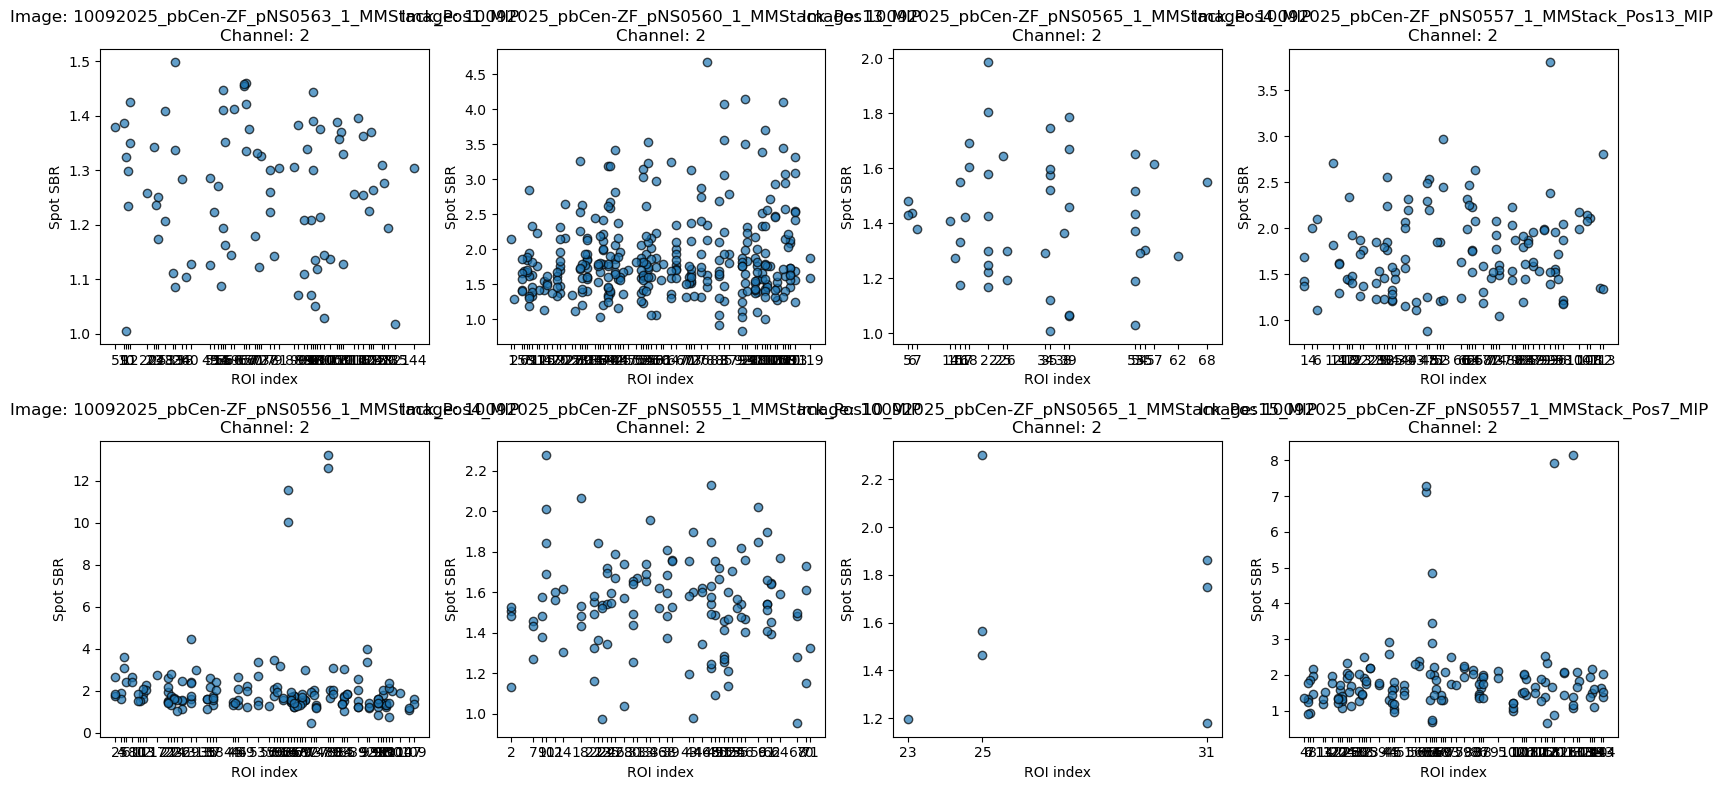

In [12]:
# Assess spot SBR distribution

# Pick images to plot, by index
selected_indices = list(range(8))

# Pick the channel to plot
c = 2

# or by name
# base_name_to_plot = "example_name"

# 1. Filter spot_metricsBS such that it includes images only with spots for channel c.

# Filter spot_counts to only include rows for channel c and a positive spot count.
images_with_spots = raw_spot_counts[(raw_spot_counts['spot_count'] > 0) & 
                                    (raw_spot_counts['channel'] == c)]['base_name'].unique()
# Filter spot_metrics to include only these images.
spot_metrics_yespots = spot_metricsBS[spot_metricsBS['base_name'].isin(images_with_spots)]

# 2. Select images to plot from the filtered data.

# Here, we'll use a selection of indices from the unique base_names in spot_metrics_yespots.
unique_base_names = spot_metrics_yespots['base_name'].unique()
images_to_plot = [unique_base_names[i] for i in selected_indices if i < len(unique_base_names)]

# Define the grid dimensions.
n_images = len(images_to_plot)
ncols = 4
nrows = int(np.ceil(n_images / ncols))

# Create subplots grid.
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), squeeze=False)

# Loop over each selected image and plot it.
for idx, base_name in enumerate(images_to_plot):
    ax = axes[idx // ncols, idx % ncols]
    
    # Filter the DataFrame for the current image.
    subset = spot_metrics_yespots[(spot_metrics_yespots['base_name'] == base_name) &
                                  (spot_metrics_yespots['channel'] == c)]
    
    print(f"{base_name} (Channel {c}): {len(subset)} spots")
    
    # Create a scatter plot: ROI index on x-axis, spot intensity on y-axis.
    ax.scatter(subset['ROI'], subset['sbr'], alpha=0.7, edgecolor='black')
    ax.set_title(f"Image: {base_name}\nChannel: {c}")
    ax.set_xlabel("ROI index")
    ax.set_ylabel("Spot SBR")
    
    # Set x-axis ticks to show unique integer ROI values.
    unique_rois = np.sort(subset['ROI'].unique())
    ax.set_xticks(unique_rois)

# Hide any unused subplots in the grid.
total_subplots = nrows * ncols
for j in range(idx + 1, total_subplots):
    fig.delaxes(axes[j // ncols, j % ncols])

plt.tight_layout()
plt.show()

In [13]:
# Calculate the relative intensity for each ROI:

# Compute the maximum intensity for each group of base_name, ROI and channel
spot_metricsBS['max_intensity'] = spot_metricsBS.groupby(['base_name', 'ROI', 'channel', 'plasmid'])['intensity'].transform('max')

# Create the a new relative intensity variable
spot_metricsBS['rel_intensity'] = spot_metricsBS['intensity'] / spot_metricsBS['max_intensity']

# Optionally, drop the intermediate columns if you don't need it anymore
spot_metricsBS.drop(columns = ['max_intensity'], inplace = True)

10092025_pbCen-ZF_pNS0555_1_MMStack_Pos10_MIP (Channel 2): 125 spots
10092025_pbCen-ZF_pNS0565_1_MMStack_Pos15_MIP (Channel 2): 7 spots
10092025_pbCen-ZF_pNS0557_1_MMStack_Pos7_MIP (Channel 2): 141 spots
10092025_pbCen-ZF_pNS0554_1_MMStack_Pos9_MIP (Channel 2): 192 spots
10092025_pbCen-ZF_pNS0567_1_MMStack_Pos9_MIP (Channel 2): 228 spots
10092025_pbCen-ZF_pNS0558_1_MMStack_Pos12_MIP (Channel 2): 151 spots


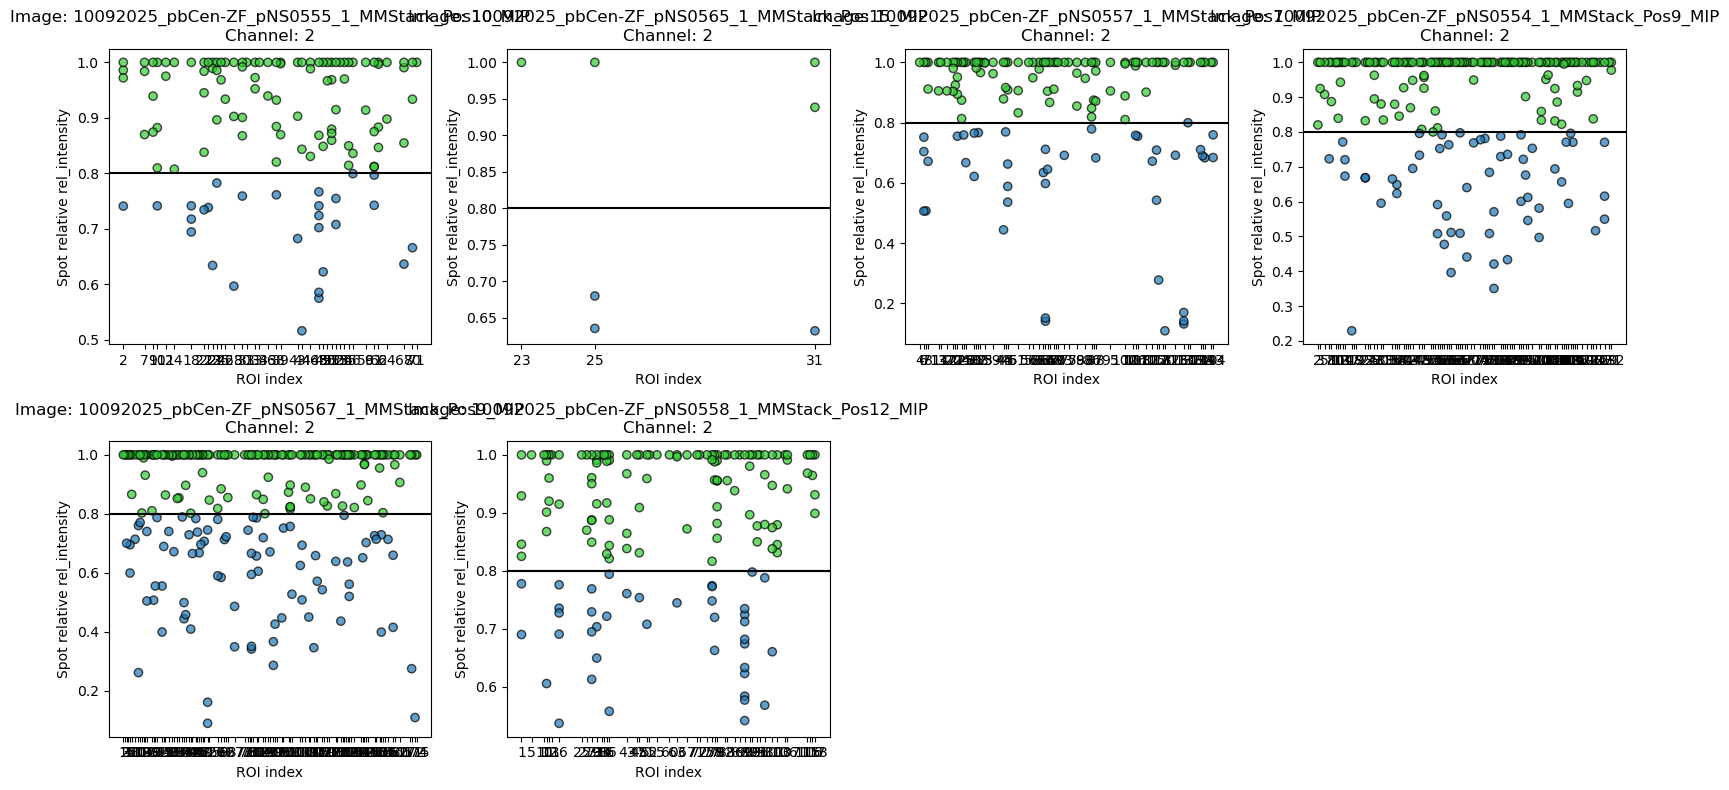

In [15]:
# Assess relative spot intensity distribution

# Pick images to plot, by index
#selected_indices = list(range(8))
selected_indices = [5, 6, 7, 8, 9, 10]

# Pick the channel to plot
c = 2

# Define the potential cutoff for spurious spots, 
# as a fraction of the brigthest spot in the cell
cutoff = 0.8

# and the metric to use
my_metric = "rel_intensity"

# or by name
# base_name_to_plot = "example_name"

# 1. Filter spot_metrics such that it includes images only with spots for channel c.

# Filter spot_counts to only include rows for channel c and a positive spot count.
images_with_spots = raw_spot_counts[(raw_spot_counts['spot_count'] > 0) & 
                                    (raw_spot_counts['channel'] == c)]['base_name'].unique()
# Filter spot_metrics to include only these images.
spot_metrics_yespots = spot_metricsBS[spot_metricsBS['base_name'].isin(images_with_spots)]

# 2. Select images to plot from the filtered data.

# Here, we'll use a selection of indices from the unique base_names in spot_metrics_yespots.
unique_base_names = spot_metrics_yespots['base_name'].unique()
images_to_plot = [unique_base_names[i] for i in selected_indices if i < len(unique_base_names)]

# Define the grid dimensions.
n_images = len(images_to_plot)
ncols = 4
nrows = int(np.ceil(n_images / ncols))

# Create subplots grid.
#fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), squeeze=False)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), squeeze=False)


# Loop over each selected image and plot it.
for idx, base_name in enumerate(images_to_plot):
    ax = axes[idx // ncols, idx % ncols]
    
    # Filter the DataFrame for the current image.
    subset = spot_metrics_yespots[(spot_metrics_yespots['base_name'] == base_name) &
                                  (spot_metrics_yespots['channel'] == c)]
    
    print(f"{base_name} (Channel {c}): {len(subset)} spots")

    # Determine the color for each spot: yellow if the value >= cutoff, otherwise default blue ("C0")
    colors = np.where(subset[my_metric] >= cutoff, "limegreen", "C0")
    
    # Create a scatter plot: ROI index on x-axis, spot intensity on y-axis.
    ax.scatter(subset['ROI'], subset[my_metric], alpha = 0.7, 
               edgecolor = 'black', color = colors)
    ax.set_title(f"Image: {base_name}\nChannel: {c}")
    ax.axhline(y=cutoff, color='k', linestyle='-')
    ax.set_xlabel("ROI index")
    ax.set_ylabel(f"Spot relative {my_metric}")
    
    # Set x-axis ticks to show unique integer ROI values.
    unique_rois = np.sort(subset['ROI'].unique())
    ax.set_xticks(unique_rois)

# Hide any unused subplots in the grid.
total_subplots = nrows * ncols
for j in range(idx + 1, total_subplots):
    fig.delaxes(axes[j // ncols, j % ncols])

plt.tight_layout()
plt.axhline(y=cutoff, color='k', linestyle='-')
plt.show()

In [16]:
# Classify spots as real or false based on the cutoff set above
# for the metric given as "my_metric"

# Add a new variable ("real_spot") to flag whether each spot is real or not (based on the given cutoff)
spot_metricsBS['real_spot'] = np.where(spot_metricsBS[my_metric] >= cutoff, "Yes", "No")

# Count the number of "real" spots (i.e., those with "Yes") per ROI, image and channel
# group by the common keys and sum up the number of "Yes" occurrences.

# Here we assume that the key columns are:
common_keys = ['experiment', 'base_name', 'ROI', 'channel', 'plasmid']

filtr_spot_counts = spot_metricsBS.groupby(common_keys).agg(
    real_spot_count = ("real_spot", lambda x: (x == "Yes").sum())
).reset_index()

# Combine filtr_spot_counts with raw_spot_counts 
# to have both the raw and filtered number of spots in one data frame
# and to incorporate ROIs with zero spots into the filtr_spot_counts

# Rename 'spot_count' in raw_spot_counts to 'raw_spot_count'
raw_spot_counts.rename(columns={'spot_count': 'raw_spot_count'}, inplace=True)

# Merge both data frames using a left merge.
# This preserves ROIs (and images) with zero raw spots.
filtr_spot_counts = pd.merge(raw_spot_counts, 
                                filtr_spot_counts, 
                                on = common_keys, 
                                how = 'left')

# Any missing real_spot_count (i.e. no real spots) are filled with 0.
filtr_spot_counts['real_spot_count'] = filtr_spot_counts['real_spot_count'].fillna(0).astype(int)

In [17]:
print(raw_spot_counts.head())
print(filtr_spot_counts.head())

                      experiment  \
0  10092025_pb-mSG_Cen-ZF_batch1   
1  10092025_pb-mSG_Cen-ZF_batch1   
2  10092025_pb-mSG_Cen-ZF_batch1   
3  10092025_pb-mSG_Cen-ZF_batch1   
4  10092025_pb-mSG_Cen-ZF_batch1   

                                      base_name  ROI  channel  raw_spot_count  \
0  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    2        2               0   
1  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    3        2               0   
2  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    5        2               1   
3  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    6        2               0   
4  10092025_pbCen-ZF_pNS0563_1_MMStack_Pos1_MIP    7        2               0   

                      plasmid  
0  pb_mSG_Cen8-ZF3a_v2_SV40pA  
1  pb_mSG_Cen8-ZF3a_v2_SV40pA  
2  pb_mSG_Cen8-ZF3a_v2_SV40pA  
3  pb_mSG_Cen8-ZF3a_v2_SV40pA  
4  pb_mSG_Cen8-ZF3a_v2_SV40pA  
                      experiment  \
0  10092025_pb-mSG_Cen-ZF_batch1   
1  10092025_pb-mSG_Cen-ZF_batch1

In [18]:
# FILE SAVING # 

# Files will be saved in the "results" folder of the analysis repository
results_dir = os.path.join(repo_directory, "results")

# Files for each experiment will be saved in their own folder as .csv files
# They can subsequently be read in and joined as needed
# This is more versatile than combining data from multiple experiments into a single big .csv file

# Get today's date string to use as a suffix
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    experiment_folder = os.path.join(results_dir, experiment)
    
    # Create the folder if it doesn't already exist
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the DataFrames for the current experiment.
    # (Assumes your spot_counts and spot_metrics DataFrames include an "experiment" column.)
    spot_counts_exp = filtr_spot_counts[filtr_spot_counts['experiment'] == experiment]
    spot_metrics_exp = spot_metricsBS[spot_metricsBS['experiment'] == experiment]
    
    # Define the default file paths for the CSV files
    spot_counts_file = os.path.join(experiment_folder, "spot_counts-filtr.csv")
    spot_metrics_file = os.path.join(experiment_folder, "spot_metrics-postBS.csv")
    
    # If the spot_counts file already exists, add the date suffix to create a new filename.
    if os.path.exists(spot_counts_file):
        spot_counts_file = os.path.join(experiment_folder, f"spot_counts-filtr_{date_suffix}.csv")
    
    # If the spot_metrics file already exists, add the date suffix to create a new filename.
    if os.path.exists(spot_metrics_file):
        spot_metrics_file = os.path.join(experiment_folder, f"spot_metrics-postBS_{date_suffix}.csv")
    
    # Save the DataFrames to their respective CSV files
    spot_counts_exp.to_csv(spot_counts_file, index=False)
    spot_metrics_exp.to_csv(spot_metrics_file, index=False)

/Users/nestor/anaconda3/envs/pyimage-env/lib/python3.12/site-packages/plotnine/themes/themeable.py:2438: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


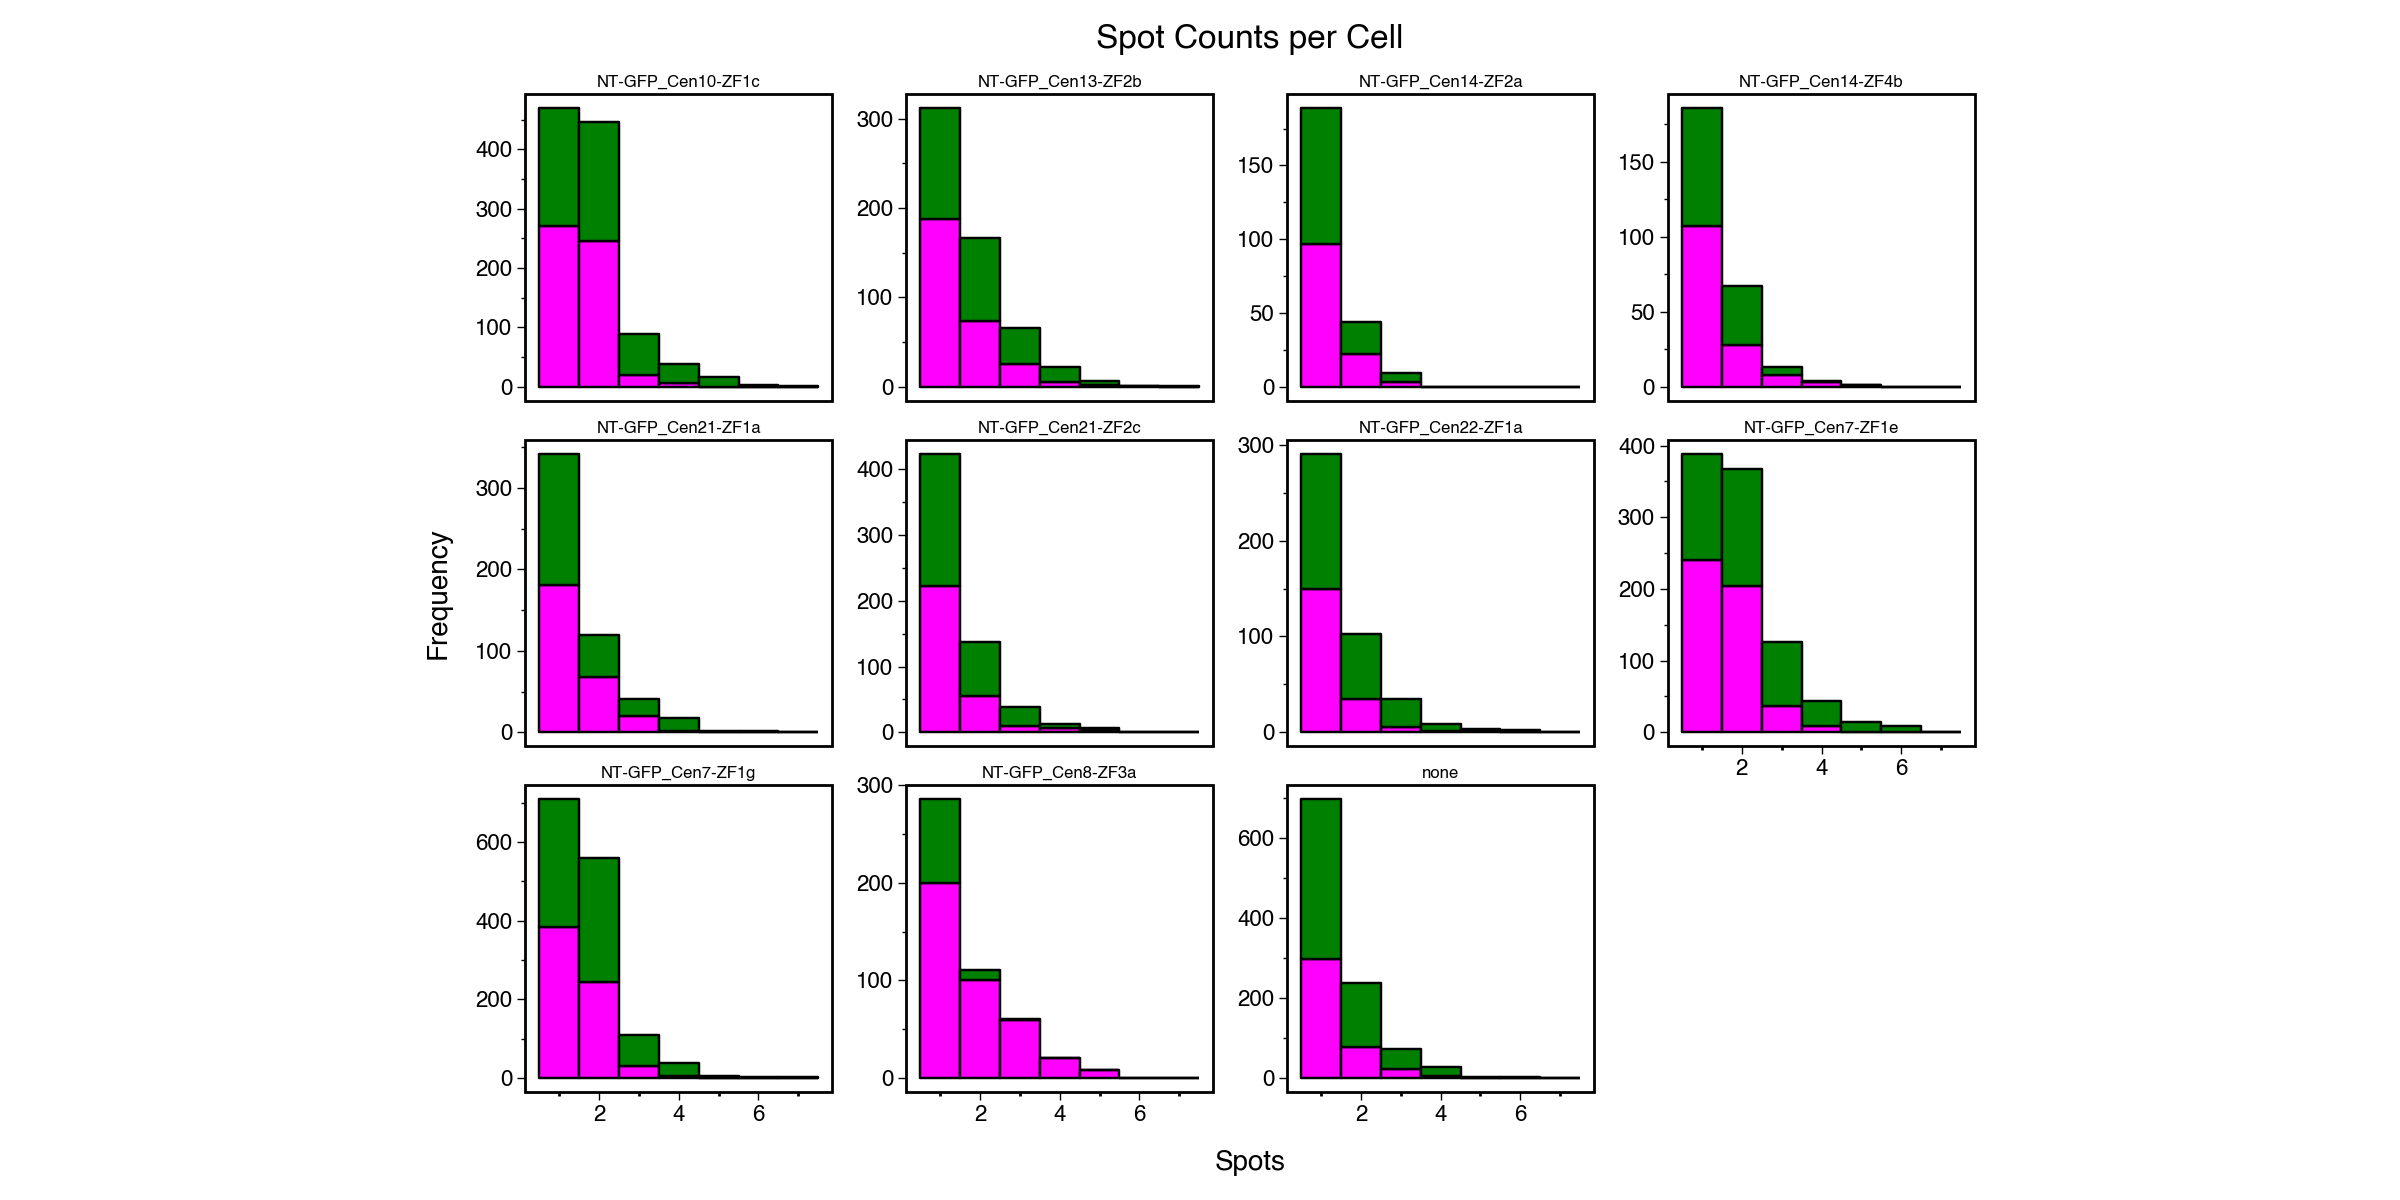

In [61]:
# Make a histogram showing the number of spots after filtering, as done earlier

# Determine the largest number of spots to set the X axis of the plot
#max_spot_count = spot_df['spot_count'].max()
max_spot_count = 8
spot_range = range(1, 8)

#my_spots = spot_filter_counts[spot_counts['channel'].isin([2,3])]
my_spots = filtr_spot_counts[(filtr_spot_counts['experiment'] == experiment_list[0]) &
                            (filtr_spot_counts['real_spot_count'].isin(spot_range))]

# Define the plot with overlaid histograms for each channel
spot_histogram_filter = (
    p9.ggplot(my_spots, 
              p9.aes(x = 'real_spot_count', 
                     fill = 'factor(channel)')) +  # Set the data and x-axis aesthetic
    p9.geom_histogram(binwidth = 1, color = 'black') +  # Overlaid histograms
    p9.labs(title = 'Spot Counts per Cell', 
            x = 'Spots', y = 'Frequency', fill = 'Channel') +  # Add labels
    #p9.facet_wrap(' ~ channel + group', scales = "free_y", nrow = 2) +
    p9.facet_wrap(' ~ test_plasmid', scales = 'free_y') +
    p9.scale_fill_manual(values = channel_colors) +  # Apply the custom channel colors
    #p9.scale_x_continuous(limits = [0, max_spot_count+1], breaks = range(0, max_spot_count + 1, 2)) + 
    p9.theme_bw() +  # Apply theme
    p9.theme(figure_size = (12, 6),
             subplots_adjust = {'wspace': 0.2},  # Adjust space between plots
             aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color='black', linewidth=1), 
             axis_ticks = p9.element_line(color='black', linewidth=0.5), 
             plot_title = p9.element_text(size=12, color='black', face='bold'),
             axis_text = p9.element_text(size=8, color='black'), 
             axis_title = p9.element_text(size=10, color='black', face='bold'), 
             legend_text = p9.element_text(size=8, color='black'), 
             legend_title = p9.element_text(size=10, color='black', face='bold'),
             legend_position = 'none',
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size=6, color='black'))
)

# Display the plot
spot_histogram_filter

In [23]:
# Optional: save the plot to "plots" inside "repo_directory"

# Define the directory to save the plot
if len(experiment_list) > 1:
    experiment_name = experiment_list[0] + "-" + experiment_list[-1]
else:
    experiment_name = experiment_list[0]

# Define the folder path: repo_directory/plots/<experiment>
plot_dir = os.path.join(repo_directory, "plots", experiment_name)
os.makedirs(plot_dir, exist_ok = True)  # Create the folder if it doesn't exist

# Give the plot a filename
plot_filename = os.path.join(plot_dir, "spot_histogram_unfiltered.png")

# Draw the Plotnine plot to obtain a Matplotlib figure
fig = spot_histogram_raw.draw()

# Save the figure as a PNG file
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
plt.close(fig)  # Close the figure after saving

print(f"Plot saved as PNG to {plot_filename}")

# Give the plot a filename
plot_filename = os.path.join(plot_dir, "spot_histogram_sbr-filtered.png")

# Draw the Plotnine plot to obtain a Matplotlib figure
fig = spot_histogram_filter.draw()

# Save the figure as a PNG file
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
plt.close(fig)  # Close the figure after saving

print(f"Plot saved as PNG to {plot_filename}")

/Users/nestor/anaconda3/envs/pyimage-env/lib/python3.12/site-packages/plotnine/themes/themeable.py:2438: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


Plot saved as PNG to /Users/nestor/Documents/NYU-ISG/python_image-analysis/plots/05062025_hCEC_mStayGold_post-sort/spot_histogram_unfiltered.png
Plot saved as PNG to /Users/nestor/Documents/NYU-ISG/python_image-analysis/plots/05062025_hCEC_mStayGold_post-sort/spot_histogram_sbr-filtered.png


/Users/nestor/anaconda3/envs/pyimage-env/lib/python3.12/site-packages/plotnine/themes/themeable.py:2438: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [24]:
print(filtr_spot_counts.head())
print(spot_metricsBS.head())

# Now combine the spot counts for each cell in each image with the 

                          experiment  \
0  05062025_hCEC_mStayGold_post-sort   
1  05062025_hCEC_mStayGold_post-sort   
2  05062025_hCEC_mStayGold_post-sort   
3  05062025_hCEC_mStayGold_post-sort   
4  05062025_hCEC_mStayGold_post-sort   

                                           base_name  ROI  channel  \
0  05062025_D29_pHAGE_mStayGold_dCas9_sorted-gate...    1        2   
1  05062025_D29_pHAGE_mStayGold_dCas9_sorted-gate...    3        2   
2  05062025_D29_pHAGE_mStayGold_dCas9_sorted-gate...    4        2   
3  05062025_D29_pHAGE_mStayGold_dCas9_sorted-gate...    5        2   
4  05062025_D29_pHAGE_mStayGold_dCas9_sorted-gate...    6        2   

   raw_spot_count                plasmid    gate  MOI  real_spot_count  
0               0  pHAGE_mStayGold_dCas9  gate_S  low                0  
1               0  pHAGE_mStayGold_dCas9  gate_S  low                0  
2               0  pHAGE_mStayGold_dCas9  gate_S  low                0  
3               0  pHAGE_mStayGold_dCas9  gate